In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
decoy_scores = pd.read_csv("/mnt/biomsarchive/biomsarchive/Data/personal/ma7631si/immunopeptides_data/outputs/binding_score_function/3_scores/decoy_scores.csv")
real_scores = pd.read_csv("/mnt/biomsarchive/biomsarchive/Data/personal/ma7631si/immunopeptides_data/outputs/binding_score_function/3_scores/scores.csv")
real_scores["is_decoy"] = False

In [3]:
real_scores["complex_filename"].head(3)

0          1vrk_RRKQKTGHAVRAIGRLSSS
1    1g5j_NLWAAQRYGRELRRMSDEFVDSFKK
2          1jsp_SHLKSKKGQSTSRHKLMFK
Name: complex_filename, dtype: object

In [13]:
print(len(real_scores.index))

real_scores = real_scores[real_scores["boltz_in_binding_site"]]

print(len(real_scores.index))

real_scores = real_scores[real_scores["alphafold_in_binding_site"]]

print(len(real_scores.index))


812
790
790


In [14]:
processed_complexes = pd.read_csv("/mnt/biomsarchive/biomsarchive/Data/personal/ma7631si/immunopeptides_data/outputs/binding_score_function/1_processed_complexes/processed_pdbs.csv")
processed_complexes["complex_filename"] = processed_complexes.pdb_code + '_' + processed_complexes.peptide_sequence
processed_complexes.head(3)

,Unnamed: 0.1,Unnamed: 0,pdb_code,resolution,release_year,binding_data,reference,ligand_name,protein_sequence,peptide_sequence,peptide_length,complex_filename
0,0,90,1vrk,1.90,1999,Kd=6.8nM,1vrk.pdf,(A|B) E84K-CALMODULIN and RS20 PEPTIDE COMPLEX...,ADQLTDEQIAEFKEAFSLFDKDGDGTITTKELGTVMRSLGQNPTEA...,RRKQKTGHAVRAIGRLSSS,19,1vrk_RRKQKTGHAVRAIGRLSSS
1,1,136,1g5j,NMR,2001,Kd=0.6nM,1g5j.pdf,"(A|B) Kd=0.6nM, 25-mer peptide from Bad",MSMAMSQSNRELVVDFLSYKLSQKGYSWSQFSDVEENRTEAPEGTE...,NLWAAQRYGRELRRMSDEFVDSFKK,25,1g5j_NLWAAQRYGRELRRMSDEFVDSFKK
2,2,199,1jsp,NMR,2002,Kd=50uM,1jsp.pdf,"(A|B) CBP bromodomain/p53 peptide complex, Kd~...",GSHMRKKIFKPEELRQALMPTLEALYRQDPESLPFRQPVDPQLLGI...,SHLKSKKGQSTSRHKLMFK,19,1jsp_SHLKSKKGQSTSRHKLMFK


In [15]:
real_scores = real_scores.merge(processed_complexes, on="complex_filename", how="inner")
real_scores.head(3)

,alphafold_iptm,alphafold_rosetta_score,alphafold_interface_sasa,alphafold_interface_dG,alphafold_interface_delta_hbond_unsat,alphafold_packstat,alphafold_distance_score,alphafold_receptor_contacts,alphafold_in_binding_site,alphafold_n_contacts,...,Unnamed: 0,pdb_code,resolution,release_year,binding_data,reference,ligand_name,protein_sequence,peptide_sequence,peptide_length
0,0.82,-244.097196,2897.656199,-58.462742,8,0.557642,6.763129,"[6, 7, 10, 11, 13, 14, 16, 17, 18, 26, 31, 34,...",True,39,...,90,1vrk,1.90,1999,Kd=6.8nM,1vrk.pdf,(A|B) E84K-CALMODULIN and RS20 PEPTIDE COMPLEX...,ADQLTDEQIAEFKEAFSLFDKDGDGTITTKELGTVMRSLGQNPTEA...,RRKQKTGHAVRAIGRLSSS,19
1,0.89,-116.028837,2405.011598,-82.866498,8,0.746928,6.417218,"[55, 56, 57, 59, 60, 63, 64, 67, 68, 71, 72, 7...",True,38,...,136,1g5j,NMR,2001,Kd=0.6nM,1g5j.pdf,"(A|B) Kd=0.6nM, 25-mer peptide from Bad",MSMAMSQSNRELVVDFLSYKLSQKGYSWSQFSDVEENRTEAPEGTE...,NLWAAQRYGRELRRMSDEFVDSFKK,25
2,0.69,122.007697,1634.904923,-39.795239,14,0.641468,6.094163,"[17, 18, 20, 21, 22, 24, 25, 28, 29, 39, 40, 4...",True,21,...,205,1jgn,NMR,2003,Kd=0.35uM,1jgn.pdf,"(A|B) PABP-interacting protein-2 (Paip2), Kd=3...",GPLGSPLTASMLASAPPQEQKQMLGERLFPLIQAMHPTLAGKITGM...,VVKSNLNPNAKEFVPGVKYGNI,22


In [16]:
UNIT_CONVERSION = {
    "fm": 1e-15,
    "pm": 1e-12,
    "nm": 1e-9,
    "um": 1e-6,
    "μm": 1e-6,
    "mm": 1e-3,
    "m": 1,
}

def process_binding_data(binding_series: pd.Series) -> pd.Series:
    """
    Convert binding strings (e.g. "< 5 µM") to pKd values.
    """
    print(f"Processing {len(binding_series)} entries; {binding_series.isna().sum()} missing.")
    
    # Analyze what would be excluded with the new regex
    new_regex = r"[=]?\s*(?P<value>\d+\.?\d*)\s*(?P<unit>[µa-zA-Z]*)"
    new_parsed = binding_series.str.extract(new_regex)

    parsed = new_parsed
    parsed["value"] = pd.to_numeric(parsed["value"], errors="coerce")
    parsed["unit"] = parsed["unit"].str.lower()
    kd_molar = parsed["value"] * parsed["unit"].map(UNIT_CONVERSION)
    pKd = -np.log10(kd_molar)

    nan_count = kd_molar.isna().sum()
    print(f"Converted: {nan_count} entries failed (NaN).")
    if nan_count:
        print(binding_series[kd_molar.isna()].head())
    return pKd

bind_map = pd.Series(real_scores.binding_data.values, index=real_scores.complex_filename)
real_scores["pKd"] = process_binding_data(real_scores.complex_filename.map(bind_map))

Processing 790 entries; 0 missing.
Converted: 97 entries failed (NaN).
31      IC50=50nM
38     IC50=0.6nM
39     IC50=500nM
40       IC50=5nM
63    IC50=0.22uM
Name: complex_filename, dtype: object


In [17]:
real_scores.dropna(subset=["pKd"], inplace=True)
real_scores.head(3)

,alphafold_iptm,alphafold_rosetta_score,alphafold_interface_sasa,alphafold_interface_dG,alphafold_interface_delta_hbond_unsat,alphafold_packstat,alphafold_distance_score,alphafold_receptor_contacts,alphafold_in_binding_site,alphafold_n_contacts,...,pdb_code,resolution,release_year,binding_data,reference,ligand_name,protein_sequence,peptide_sequence,peptide_length,pKd
0,0.82,-244.097196,2897.656199,-58.462742,8,0.557642,6.763129,"[6, 7, 10, 11, 13, 14, 16, 17, 18, 26, 31, 34,...",True,39,...,1vrk,1.90,1999,Kd=6.8nM,1vrk.pdf,(A|B) E84K-CALMODULIN and RS20 PEPTIDE COMPLEX...,ADQLTDEQIAEFKEAFSLFDKDGDGTITTKELGTVMRSLGQNPTEA...,RRKQKTGHAVRAIGRLSSS,19,8.167491
1,0.89,-116.028837,2405.011598,-82.866498,8,0.746928,6.417218,"[55, 56, 57, 59, 60, 63, 64, 67, 68, 71, 72, 7...",True,38,...,1g5j,NMR,2001,Kd=0.6nM,1g5j.pdf,"(A|B) Kd=0.6nM, 25-mer peptide from Bad",MSMAMSQSNRELVVDFLSYKLSQKGYSWSQFSDVEENRTEAPEGTE...,NLWAAQRYGRELRRMSDEFVDSFKK,25,9.221849
2,0.69,122.007697,1634.904923,-39.795239,14,0.641468,6.094163,"[17, 18, 20, 21, 22, 24, 25, 28, 29, 39, 40, 4...",True,21,...,1jgn,NMR,2003,Kd=0.35uM,1jgn.pdf,"(A|B) PABP-interacting protein-2 (Paip2), Kd=3...",GPLGSPLTASMLASAPPQEQKQMLGERLFPLIQAMHPTLAGKITGM...,VVKSNLNPNAKEFVPGVKYGNI,22,6.455932


<Axes: xlabel='alphafold_interface_dG', ylabel='pKd'>

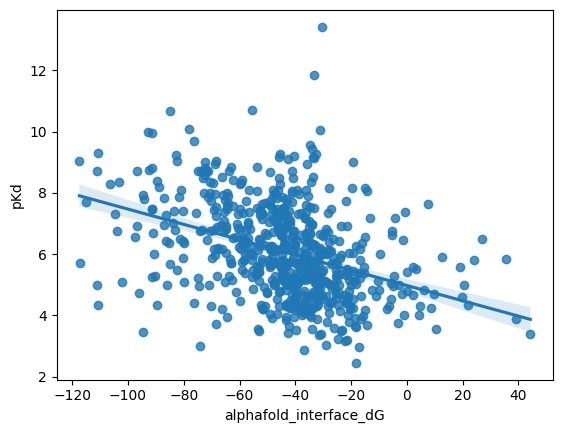

In [18]:
real_scores = real_scores[real_scores["alphafold_interface_dG"] < 100]
real_scores = real_scores[real_scores["alphafold_interface_dG"] > -200]
real_scores = real_scores[real_scores["boltz_interface_dG"] < 200]

sns.regplot(data=real_scores, x="alphafold_interface_dG", y="pKd")

<Axes: xlabel='alphafold_ipsae_max', ylabel='pKd'>

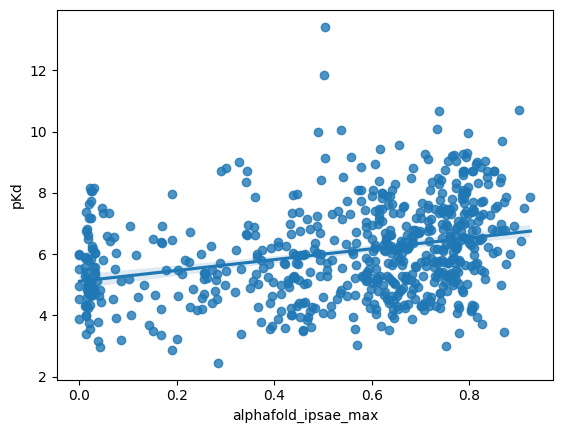

In [19]:
sns.regplot(data=real_scores, y="pKd", x="alphafold_ipsae_max")

In [20]:
real_scores.columns

Index(['alphafold_iptm', 'alphafold_rosetta_score', 'alphafold_interface_sasa',
       'alphafold_interface_dG', 'alphafold_interface_delta_hbond_unsat',
       'alphafold_packstat', 'alphafold_distance_score',
       'alphafold_receptor_contacts', 'alphafold_in_binding_site',
       'alphafold_n_contacts', 'alphafold_in_binding_site_score',
       'alphafold_template_rmsd', 'alphafold_peptide_plddt',
       'alphafold_interface_peptide_plddt', 'alphafold_peptide_pae',
       'boltz_iptm', 'boltz_confidence_score', 'boltz_complex_plddt',
       'boltz_complex_iplddt', 'boltz_complex_pde', 'boltz_complex_ipde',
       'boltz_ligand_iptm', 'boltz_protein_iptm', 'boltz_chain_0_ptm',
       'boltz_chain_1_ptm', 'boltz_rosetta_score', 'boltz_interface_sasa',
       'boltz_interface_dG', 'boltz_interface_delta_hbond_unsat',
       'boltz_packstat', 'boltz_distance_score', 'boltz_receptor_contacts',
       'boltz_in_binding_site', 'boltz_n_contacts',
       'boltz_in_binding_site_score', 'bol

<Axes: xlabel='boltz_ipsae_min', ylabel='intra_boltz_mean_rmsd'>

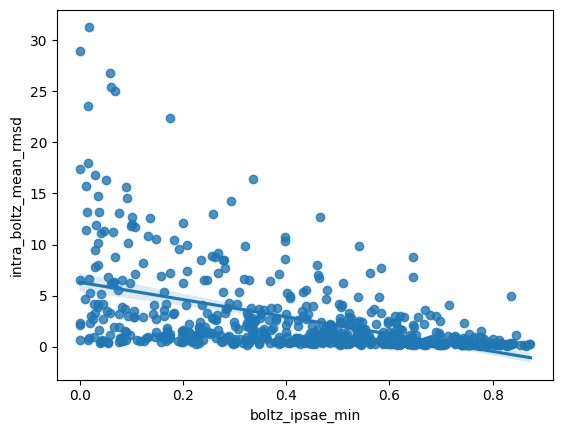

In [21]:
sns.regplot(data=real_scores, x="boltz_ipsae_min", y="intra_boltz_mean_rmsd")

In [22]:
merged = pd.concat([decoy_scores, real_scores], ignore_index=True)
merged

,alphafold_iptm,alphafold_rosetta_score,alphafold_interface_sasa,alphafold_interface_dG,alphafold_interface_delta_hbond_unsat,alphafold_packstat,alphafold_distance_score,alphafold_receptor_contacts,alphafold_in_binding_site,alphafold_n_contacts,...,pdb_code,resolution,release_year,binding_data,reference,ligand_name,protein_sequence,peptide_sequence,peptide_length,pKd
0,0.73,-160.044795,1793.787574,-40.289201,2,0.643482,6.590172,"[55, 58, 59, 62, 63, 66, 67, 69, 70, 73, 74, 8...",True,26,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0.53,-450.190915,1150.107183,-10.208492,2,0.659416,6.917019,"[43, 44, 47, 48, 50, 51, 56, 57, 61, 62, 64, 6...",True,19,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0.52,-138.012738,799.427872,-19.924854,3,0.723829,5.725480,"[16, 17, 20, 21, 24, 47, 52, 53, 54, 55, 56, 5...",True,7,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0.61,-882.417598,2146.989948,-39.832360,16,0.628115,6.316949,"[24, 25, 26, 27, 28, 70, 126, 129, 133, 149, 1...",True,28,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0.35,181.241224,1456.402406,-9.086313,5,0.690708,6.099788,"[5, 8, 9, 10, 24, 26, 27, 28, 29, 31, 32, 33, ...",True,21,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1436,0.92,-606.931843,1005.478357,-42.739885,0,0.432788,7.133572,"[40, 41, 44, 45, 47, 48, 53, 58, 59, 61, 62, 6...",True,13,...,6gg8,1.80,2019.0,Ki=0.79nM,6gg8.pdf,"(EY8) pKi=9.1, compound is (R)-36",SPVMVLENIEPEIVYAGYDSSKPDTAENLLSTLNRLAGKQMIQVVK...,KSLLQQLLTE,10.0,9.102373
1437,0.93,-632.341379,1045.493939,-41.136505,0,0.503671,7.044384,"[42, 43, 46, 47, 49, 50, 55, 60, 61, 63, 64, 6...",True,14,...,6gev,1.54,2019.0,Ki=2.00nM,6gev.pdf,"(EWN) pKi=8.7, compound is (S)-13",YFSPVMVLENIEPEIVYAGYDSSKPDTAENLLSTLNRLAGKQMIQV...,KSLLQQLLTE,10.0,8.698970
1438,0.57,-356.965533,868.454116,-15.478414,3,0.709058,6.663701,"[93, 94, 95, 96, 125, 141, 143, 146, 147, 148,...",True,7,...,6hy7,2.26,2019.0,Ki=2.7uM,6hy7.pdf,(13-mer) ligand is RgIA,DGKYAQKLFNDLFEDYSNALRPVEDTDKVLNVTLQITLSQIKDMDE...,GCCSDPRCRYRC,12.0,5.568636
1439,0.93,-640.567598,1118.024571,-41.135689,1,0.471399,7.217682,"[42, 43, 44, 46, 47, 49, 50, 55, 56, 60, 61, 6...",True,18,...,6nwk,1.65,2019.0,Ki=20nM,6nwk.pdf,(DEX) ligand is DEX,FPTLISLLEVIEPEVLYSGYDSTLPDTSTRLMSTLNRLGGRQVVSA...,PSLLKKLLLAPA,12.0,7.698970


In [23]:
merged.columns

Index(['alphafold_iptm', 'alphafold_rosetta_score', 'alphafold_interface_sasa',
       'alphafold_interface_dG', 'alphafold_interface_delta_hbond_unsat',
       'alphafold_packstat', 'alphafold_distance_score',
       'alphafold_receptor_contacts', 'alphafold_in_binding_site',
       'alphafold_n_contacts', 'alphafold_in_binding_site_score',
       'alphafold_template_rmsd', 'alphafold_peptide_plddt',
       'alphafold_interface_peptide_plddt', 'alphafold_peptide_pae',
       'alphafold_ipsae_max', 'alphafold_ipsae_min', 'boltz_iptm',
       'boltz_confidence_score', 'boltz_complex_plddt', 'boltz_complex_iplddt',
       'boltz_complex_pde', 'boltz_complex_ipde', 'boltz_ligand_iptm',
       'boltz_protein_iptm', 'boltz_chain_0_ptm', 'boltz_chain_1_ptm',
       'boltz_rosetta_score', 'boltz_interface_sasa', 'boltz_interface_dG',
       'boltz_interface_delta_hbond_unsat', 'boltz_packstat',
       'boltz_distance_score', 'boltz_receptor_contacts',
       'boltz_in_binding_site', 'boltz_n_

<Axes: xlabel='boltz_iptm', ylabel='Density'>

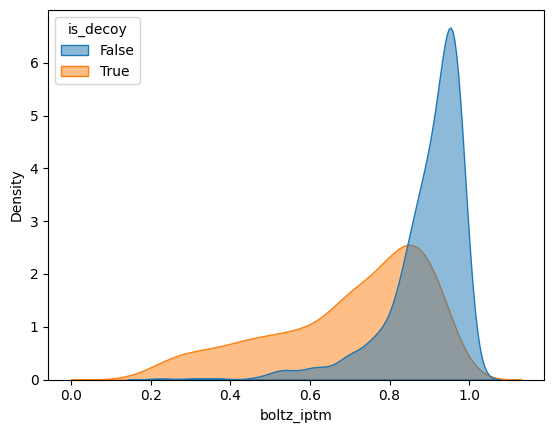

In [24]:
sns.kdeplot(merged, x="boltz_iptm", hue="is_decoy", fill=True, common_norm=False, alpha=0.5)